# PlantCare AI — demonstracja działania

Notatnik uruchamia kluczowe elementy projektu na realnych danych:

1. **CLIP (zero-shot)** — rozpoznawanie gatunku rośliny ze zdjęcia (moduł `src/vision/clip_classifier.py`).
2. **Embeddingi + FAISS** — wyszukiwanie semantyczne fragmentów (ten sam model i metryka co `src/retrieval/vector_store.py`).

Elementy wymagające kluczy API (SerpAPI — wyszukiwanie w sieci; OpenAI — odpowiedzi LLM i agent) nie są tu wykonywane na żywo; opisano je na końcu notatnika.

Zdjęcia testowe pobierane są automatycznie z Wikimedia Commons.

## 1. Konfiguracja środowiska

In [1]:
import sys, os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'config.py').exists() and (ROOT.parent / 'config.py').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
print('Katalog projektu:', ROOT)

Katalog projektu: C:\Users\szymo\Documents\houseplant-care-ai


## 2. Pobranie zdjęć testowych (Wikimedia Commons)

Dla kilku gatunków pobieramy po jednym zdjęciu. Fraza wyszukiwania pełni rolę etykiety odniesienia (*ground truth*) przy ocenie trafności CLIP.

In [2]:
import time
from io import BytesIO
import requests
from PIL import Image

IMG_DIR = ROOT / 'assets' / 'sample_images'
IMG_DIR.mkdir(parents=True, exist_ok=True)
UA = {'User-Agent': 'PlantCareAI-demo/1.0 (educational project; plant recognition demo)'}

# (tytuł na Wikipedii, fraza w Commons, nazwa pliku, oczekiwany gatunek)
TARGETS = [
    ('Monstera deliciosa',      'Monstera deliciosa plant',       'monstera.jpg',    'Monstera deliciosa'),
    ('Sansevieria trifasciata', 'Sansevieria trifasciata',        'sansevieria.jpg', 'Sansevieria (wężownica)'),
    ('Aloe vera',               'Aloe vera plant',                'aloe.jpg',        'Aloe vera'),
    ('Epipremnum aureum',       'Epipremnum aureum pothos',       'pothos.jpg',      'Pothos (Epipremnum)'),
    ('Phalaenopsis',            'Phalaenopsis orchid',            'orchid.jpg',      'Storczyk (Phalaenopsis)'),
]

def _is_image(b):
    try:
        Image.open(BytesIO(b)).verify()
        return True
    except Exception:
        return False

def wiki_image_urls(title):
    try:
        url = 'https://en.wikipedia.org/api/rest_v1/page/summary/' + title.replace(' ', '_')
        s = requests.get(url, headers=UA, timeout=30).json()
        return [s.get(k, {}).get('source') for k in ('originalimage', 'thumbnail') if s.get(k)]
    except Exception:
        return []

def commons_image_urls(term, width=600):
    api = 'https://commons.wikimedia.org/w/api.php'
    params = {
        'action': 'query', 'format': 'json', 'generator': 'search',
        'gsrnamespace': 6, 'gsrsearch': term, 'gsrlimit': 8,
        'prop': 'imageinfo', 'iiprop': 'url', 'iiurlwidth': width,
    }
    try:
        data = requests.get(api, params=params, headers=UA, timeout=30).json()
    except Exception:
        return []
    pages = data.get('query', {}).get('pages', {})
    urls = []
    for p in sorted(pages.values(), key=lambda x: x.get('index', 99)):
        info = p.get('imageinfo', [{}])[0]
        for key in ('url', 'thumburl'):  # oryginał ma pierwszeństwo (mniej throttlingu niż host miniatur)
            u = info.get(key)
            if u and u.lower().rsplit('.', 1)[-1] in ('jpg', 'jpeg', 'png'):
                urls.append(u)
    return urls

def fetch(url, tries=4):
    for t in range(tries):
        try:
            r = requests.get(url, headers=UA, timeout=40)
        except Exception:
            return None
        if r.status_code == 200 and _is_image(r.content):
            return r.content
        if r.status_code == 429:  # rate limit — odczekaj i ponów
            time.sleep(3 * (t + 1)); continue
        return None
    return None

def download_valid(title, term):
    for u in wiki_image_urls(title) + commons_image_urls(term):
        data = fetch(u)
        if data:
            return data
        time.sleep(1)
    return None

def save_resized(data, dest, max_side=512):
    img = Image.open(BytesIO(data)).convert('RGB')
    img.thumbnail((max_side, max_side))
    img.save(dest, 'JPEG', quality=85)

samples = []
for title, term, fname, expected in TARGETS:
    dest = IMG_DIR / fname
    ok = dest.exists() and _is_image(dest.read_bytes())
    if not ok:
        data = download_valid(title, term)
        if not data:
            print('  ! brak prawidłowego obrazu dla', expected); continue
        save_resized(data, dest)
    samples.append((dest, expected))
    print(f'OK  {fname:16s} <- {expected}  ({dest.stat().st_size // 1024} KB)')
    time.sleep(0.5)

print(f'\nGotowych zdjęć: {len(samples)} (katalog {IMG_DIR})')

OK  monstera.jpg     <- Monstera deliciosa  (88 KB)


OK  sansevieria.jpg  <- Sansevieria (wężownica)  (42 KB)


OK  aloe.jpg         <- Aloe vera  (53 KB)


OK  pothos.jpg       <- Pothos (Epipremnum)  (197 KB)


OK  orchid.jpg       <- Storczyk (Phalaenopsis)  (36 KB)



Gotowych zdjęć: 5 (katalog C:\Users\szymo\Documents\houseplant-care-ai\assets\sample_images)


## 3. Rozpoznawanie gatunku — CLIP (zero-shot)

Ładujemy klasyfikator z projektu i klasyfikujemy każde zdjęcie. Model `openai/clip-vit-base-patch32` pobierany jest przy pierwszym użyciu.

In [3]:
from src.vision.clip_classifier import get_classifier

clf = get_classifier()
print('Model CLIP:', clf.model_name, '| urządzenie:', clf.device,
      '| liczba klas:', len(clf.prompts))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Model CLIP: openai/clip-vit-base-patch32 | urządzenie: cpu | liczba klas: 30


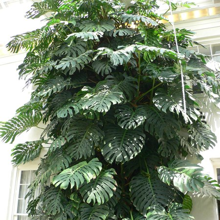

Plik: monstera.jpg  | oczekiwano: Monstera deliciosa
   1. Filodendron (Philodendron)                     36.0%
   2. Monstera dziurawa (Monstera deliciosa)         25.1%
   3. Kroton (Codiaeum variegatum)                   12.4%
----------------------------------------------------------------------


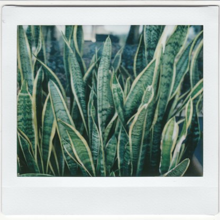

Plik: sansevieria.jpg  | oczekiwano: Sansevieria (wężownica)
   1. Sansewieria / Wężownica (Sansevieria)          58.9%
   2. Dracena (Dracaena)                             17.6%
   3. Zielistka (Chlorophytum comosum)                5.7%
----------------------------------------------------------------------


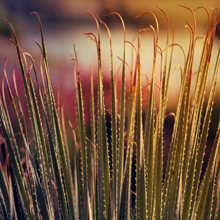

Plik: aloe.jpg  | oczekiwano: Aloe vera
   1. Aloes (Aloe vera)                              32.7%
   2. Kaktus                                         26.2%
   3. Zielistka (Chlorophytum comosum)               23.4%
----------------------------------------------------------------------


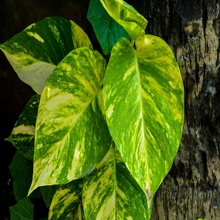

Plik: pothos.jpg  | oczekiwano: Pothos (Epipremnum)
   1. Epipremnum / Pothos (Epipremnum aureum)        49.4%
   2. Difenbachia (Dieffenbachia)                    12.6%
   3. Aglaonema (Aglaonema)                          11.4%
----------------------------------------------------------------------


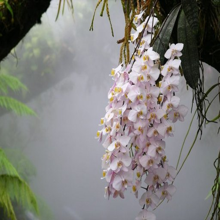

Plik: orchid.jpg  | oczekiwano: Storczyk (Phalaenopsis)
   1. Storczyk (Phalaenopsis)                        87.8%
   2. Begonia (Begonia)                               6.5%
   3. Hoja / Woskownica (Hoya)                        3.3%
----------------------------------------------------------------------


In [4]:
results = []
for path, expected in samples:
    img = Image.open(path)
    preds = clf.classify(img, top_k=3)
    top1 = preds[0]
    results.append({
        'plik': path.name,
        'oczekiwano': expected,
        'top1': top1.common,
        'pewnosc': top1.score,
        'top3': [(p.common, round(p.score, 3)) for p in preds],
    })
    display(img.convert('RGB').resize((220, 220)))
    print(f"Plik: {path.name}  | oczekiwano: {expected}")
    for i, p in enumerate(preds, 1):
        print(f"   {i}. {p.common:45s} {p.score:6.1%}")
    print('-' * 70)

### Podsumowanie rozpoznawania

In [5]:
print(f"{'plik':16s} {'oczekiwano':28s} {'CLIP top-1':30s} {'pewność':>8s}")
print('=' * 86)
for r in results:
    print(f"{r['plik']:16s} {r['oczekiwano']:28s} {r['top1']:30s} {r['pewnosc']:7.1%}")

plik             oczekiwano                   CLIP top-1                      pewność
monstera.jpg     Monstera deliciosa           Filodendron (Philodendron)       36.0%
sansevieria.jpg  Sansevieria (wężownica)      Sansewieria / Wężownica (Sansevieria)   58.9%
aloe.jpg         Aloe vera                    Aloes (Aloe vera)                32.7%
pothos.jpg       Pothos (Epipremnum)          Epipremnum / Pothos (Epipremnum aureum)   49.4%
orchid.jpg       Storczyk (Phalaenopsis)      Storczyk (Phalaenopsis)          87.8%


## 4. Embeddingi + baza wektorowa FAISS

Demonstracja warstwy retrieval z RAG. Używamy tego samego modelu embeddingów (`sentence-transformers/all-MiniLM-L6-v2`) i metryki (kosinusowa = iloczyn skalarny wektorów znormalizowanych) co `src/retrieval/vector_store.py`, tutaj bezpośrednio na FAISS, bez otoczki LangChain.

In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np, faiss

emb = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

docs = [
    'Monstera deliciosa prefers bright, indirect light and tolerates some shade.',
    'Water Monstera when the top 2-3 cm of soil is dry; avoid letting it sit in water.',
    'Monstera enjoys higher humidity; mist the leaves or use a humidity tray.',
    'Snake plants (Sansevieria) tolerate low light and need very little water.',
    'Aloe vera is a succulent that needs full sun and infrequent, deep watering.',
    'Fertilize most houseplants monthly during the growing season in spring and summer.',
]

vecs = emb.encode(docs, normalize_embeddings=True).astype('float32')
index = faiss.IndexFlatIP(vecs.shape[1])
index.add(vecs)
print(f'Zaindeksowano {index.ntotal} fragmentów, wymiar wektora = {vecs.shape[1]}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\szymo\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\szymo\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Zaindeksowano 6 fragmentów, wymiar wektora = 384


In [7]:
query = 'How often should I water my Monstera?'
qv = emb.encode([query], normalize_embeddings=True).astype('float32')
scores, idx = index.search(qv, 3)

print('Zapytanie:', query, '\n')
print('Najtrafniejsze fragmenty (similarity search):')
for rank, (i, s) in enumerate(zip(idx[0], scores[0]), 1):
    print(f'  {rank}. [score={s:.3f}] {docs[i]}')

Zapytanie: How often should I water my Monstera? 

Najtrafniejsze fragmenty (similarity search):
  1. [score=0.616] Water Monstera when the top 2-3 cm of soil is dry; avoid letting it sit in water.
  2. [score=0.508] Monstera enjoys higher humidity; mist the leaves or use a humidity tray.
  3. [score=0.323] Snake plants (Sansevieria) tolerate low light and need very little water.


## 5. Elementy wymagające kluczy API (nie wykonywane tutaj)

Pełny pipeline RAG i agent korzystają z usług zewnętrznych, dlatego nie są uruchamiane w tym notatniku bez kluczy:

- **SerpAPI** (`src/retrieval/web_search.py`) — pobranie realnych artykułów o pielęgnacji z Google.
- **OpenAI `gpt-4o-mini`** (`src/llm/chatbot.py`, `src/agent/agent.py`) — generacja odpowiedzi RAG i sterowanie agentem (tool calling).

Aby uruchomić całość: uzupełnij `OPENAI_API_KEY` i `SERPAPI_API_KEY` w pliku `.env`, a następnie `streamlit run app.py`.

Powyżej zweryfikowano realnie dwie warstwy działające lokalnie (CLIP oraz embeddingi + FAISS), które stanowią rdzeń rozpoznawania i wyszukiwania semantycznego.